In [12]:
import sys
import numpy as np
from numpy import matrix
import emcee
import astropy.io.fits as pyfits
%matplotlib inline
import matplotlib.pylab as pl
import random,os
from astropy.cosmology import FlatLambdaCDM
from scipy import optimize
from multiprocessing import Pool
from multiprocessing import cpu_count
import time
from astropy.io import ascii
from astropy.table import Table
import numpy.ma as ma


c = 300000. # km/sec
q=-0.59 # decelertion parameter


# Eqn 9 of Bruns 2018
def distmod(h,z1,z2):
    t1 = (1+z1)/(1+z2)
    t2 = (c*z2)/h
    t3 = 1 + ((1-q)*z1/2)
    return (5*np.log10(t1*t2*t3)) +25

# Getting results
#filter = ['u','B','g','V','r','i','Y','J','H']

filter=['B']
for i in range(len(filter)):

    result = ascii.read('../../results/'+filter[i]+'_ceph_update3_result.txt')
    #result = ascii.read('../results/F24Table4.txt')
    p0=result['p0'][0]
    ep0 = (result['p0'][1]+result['p0'][2])/2
    p1=result['p1'][0]
    ep1 = (result['p1'][1]+result['p1'][2])/2
    p2=result['p2'][0]
    ep2 = (result['p2'][1]+result['p2'][2])/2
    alpha=result['alpha'][0]
    ealpha = (result['alpha'][1]+result['alpha'][2])/2

    rv=result['beta'][0]
    erv = (result['beta'][1]+result['beta'][2])/2
    sig=result['sig_int'][0]
    vel=result['vel'][0]
    h0=result['H0'][0]
    eh0 = (result['H0'][1]+result['H0'][2])/2

    #p0 =-19.19
    #p1 = -1.25
    #p2 = -1.23
    #alpha = -0.02
    #rv = 3.03
    
    tab = ascii.read('../../data/working/'+filter[i]+'_ceph_update3.csv')
   
    w = np.where((tab['sn']!='CSP14abk') &  (tab['sn']!='PTF13dyt') &  (tab['sn']!='PTF13dym') & (tab['sn']!='PTF14yw') & (tab['sn']!='PS1-13eao') & (tab['subtype']!='Ia-SC') & (tab['subtype']!='Ia-02cx') & (tab['sn']!='LSQ14fmg')& (tab['sn']!='SN2004dt')& (tab['sn']!='SN2005gj')& (tab['sn']!='SN2005hk')& (tab['sn']!='SN2006bt')& (tab['sn']!='SN2006ot')& (tab['sn']!='SN2007so')& (tab['sn']!='SN2008ae')& (tab['sn']!='SN2008bd')& (tab['sn']!='SN2008ha')& (tab['sn']!='SN2008J')& (tab['sn']!='SN2009dc')& (tab['sn']!='SN2009J')& (tab['sn']!='SN2010ae'))
    
    st = tab['st'][w]
    est = tab['est'][w]
    zhel = tab['zhel'][w]
    zcmb = tab['zcmb'][w]
    mmax = tab['Mmax'][w]
    emmax = tab['eMmax'][w]
    bv = tab['BV'][w]
    ebv = tab['eBV'][w]
    m_csp = tab['m'][w]
    ml = tab['ml'][w]
    mu = tab['mu'][w]
    eml = (tab['m'][w]-tab['ml'][w])
    emu = (tab['mu'][w]-tab['m'][w])
    em = (eml+emu)/2.
    dist = tab['dist'][w]
    edist = tab['edist'][w]
    c_ms = tab['covMs'][w]
    c_mbv = tab['covBV_M'][w]
    #c_sbv = tab['covBVs'][w]

    sn = tab['sn'][w]
    sample = tab['sample'][w]
    cal = tab['caltype'][w]
    host = tab['host'][w]
    source = tab['sample'][w]
    ww =np.where(sn =='SNhunt281')
    subtype = tab['subtype'][w] 
    Ho_dist = tab['dist'][w]<0

    st1 = p1*(st - 1)
    st2 = p2*((st - 1)**2)
    red = rv*(bv)
    


In [13]:
    mmax_corr = mmax + st1 + st2 + red + alpha*(m_csp-np.median(m_csp)) 

    mu_model = np.where(Ho_dist,distmod(h0,zhel,zcmb), dist)
    fac= (p1+(2*p2*st))

    #err = (emmax**2) + ((fac*est)**2) +((rv*ebv)**2) -(2*fac*c_ms)+(2*rv*fac*c_sbv) -(2*fac*c_mbv)+((alpha*em)**2) + (sig**2) #+ ((0.00000723*vel/zcmb)**2)
        
    #err1 = (emmax**2) + ((fac*est)**2) +((rv*ebv)**2) -(2*fac*c_ms)+(2*rv*fac*c_sbv) -(2*fac*c_mbv)+((alpha*em)**2)  + (edist**2)
            
    err = (fac*est)**2 +emmax**2 +(rv*ebv)**2+2*fac*c_ms+rv*c_mbv+sig**2 +(alpha*em)**2
    err1 = ((fac*est)**2) +(emmax**2) +((rv*ebv)**2)+(2*fac*c_ms)+(rv*c_mbv)+sig**2+(edist**2)+(alpha*em)**2#
    
    mu_stat = np.where(dist<0,err,err1)
    #mu_stat=np.sqrt(err)
    
    data=Table()
    data['sn']=sn
    #data['res']=dmu

    data['mmax_snoopy'] = mmax.round(3)
    data['mmax_corrected']=mmax_corr.round(3)
    data['err_mmax']=mu_stat.round(3)
    data['host'] = host
    data['Source'] = source 
    data['Source'] = ma.filled(source, 'N/A')

    nocsp = np.where(data['Source']=='N/A')
    print(data)
    #pl.errorbar(zcmb,emmax,yerr=emmax*0,fmt='ko',alpha=0.3)
    #pl.errorbar(zcmb[nocsp],emmax[nocsp],yerr=emmax[nocsp]*0,fmt='bo',alpha=0.5)

    
    ascii.write(data,'../../results/forAdam/Ceph_'+filter[i]+'_update3.txt',format='tab',overwrite=True)
    
   


    sn    mmax_snoopy mmax_corrected err_mmax  host Source
--------- ----------- -------------- -------- ----- ------
 ASAS14ad      16.233         16.192    0.033    --  CSPII
 ASAS14hp      16.498         16.277     0.03    --  CSPII
 ASAS14hr      17.082         17.433    0.032    --  CSPII
 ASAS14hu      15.386           15.2     0.03    --  CSPII
 ASAS14jc      15.682         17.056    0.031    --  CSPII
 ASAS14jg      14.781         14.593    0.073    --  CSPII
 ASAS14jz      14.622         14.513     0.03    --  CSPII
 ASAS14kd      16.244         16.751     0.03    --  CSPII
 ASAS14kq      16.591         16.371    0.032    --  CSPII
 ASAS14lo      16.003         16.425    0.073    --  CSPII
      ...         ...            ...      ...   ...    ...
  SN2014I      16.296         16.412     0.03    --  CSPII
  SN2014Z       15.54         15.518    0.076    --  CSPII
 SN2014ao      16.919         18.824     0.03    --  CSPII
 SN2014at      16.389         16.335     0.03    --  CSP

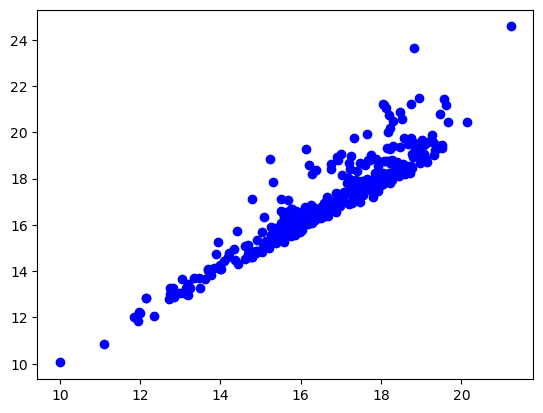

In [14]:
pl.plot(mmax, mmax_corr, 'bo')
pl.show()